In [1]:
import os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

In [2]:
import numpy as np
from soil_diskin.utils import *
import scipy as sp
from scipy.integrate import solve_ivp, cumulative_trapezoid
# from diffrax import diffeqsolve, ODETerm, Dopri5, SaveAt
import matplotlib.pyplot as plt
from soil_diskin.compartmental_models import *
import pandas as pd
from soil_diskin.constants import *
from  scipy.io import loadmat
# autoreload modules
%load_ext autoreload
%autoreload 2

### Test JSBACH (Yasso) model with varying inputs

In [35]:
# Load the site data
site_data = pd.read_csv('results/processed_balesdent_2018.csv')
turnover_14C = pd.read_csv('results/all_sites_14C_turnover.csv')

print("Generating JSBACH model predictions...")
# from https://pure.mpg.de/rest/items/item_3279802_26/component/file_3316522/content#page=107.51 and 
# https://gitlab.dkrz.de/icon/icon-model/-/blob/release-2024.10-public/externals/jsbach/src/carbon/mo_carbon_process.f90
a_i=np.array([0.72, 5.9, 0.28, 0.031]) # Eq. 6.28
a_h = 0.0016 # Eq. 6.34
b1 = 9.5e-2; b2 = -1.4e-3; gamma = -1.21; # Eq. 6.30 - T in C and P in m/yr
phi1 = -1.71; phi2 = 0.86; r = -0.306; # Eq. 6.31

# Load the JSBACH forcing data and calculate the monthly means
JSBACH_tas = xr.open_dataarray('data/model_params/JSBACH/JSBACH_S3_tas.nc').groupby("time.month").mean()
JSBACH_pr = xr.open_dataarray('data/model_params/JSBACH/JSBACH_S3_pr.nc').groupby("time.month").mean()
JSBACH_npp = xr.open_dataarray('data/model_params/JSBACH/JSBACH_S3_npp.nc').groupby("time.month").mean()

def interp_da(da):
    da = da.rio.write_crs("EPSG:4326")
    da = da.rio.write_nodata(np.nan)
    da = da.rio.interpolate_na()
    return da
JSBACH_tas = interp_da(JSBACH_tas)
JSBACH_pr = interp_da(JSBACH_pr)
JSBACH_npp = interp_da(JSBACH_npp)

JSBACH_config = namedtuple('Config', ['a_i', 'a_h', 'b1', 'b2', 'gamma', 'phi1', 'phi2', 'r'])
JSBACH_config.a_i = a_i
JSBACH_config.a_h = a_h
JSBACH_config.b1 = b1
JSBACH_config.b2 = b2
JSBACH_config.gamma = gamma
JSBACH_config.phi1 = phi1
JSBACH_config.phi2 = phi2
JSBACH_config.r = r

def get_env_params(row):
    """Get the environmental parameters for a given site."""
    I = JSBACH_npp.sel(longitude=row.loc['Longitude'], latitude=row.loc['Latitude'], method='nearest').values * SECS_PER_DAY * DAYS_PER_YEAR * 1000  # convert kgC/m2/s to gC/m2/yr
    T = JSBACH_tas.sel(longitude=row.loc['Longitude'], latitude=row.loc['Latitude'], method='nearest').values - T_MELT  # convert K to C
    P = JSBACH_pr.sel(longitude=row.loc['Longitude'], latitude=row.loc['Latitude'], method='nearest').values * SECS_PER_DAY * DAYS_PER_YEAR / 1000  # convert kg/m2/s to m/yr
    d = 4  # from WoodLitterSize in https://gitlab.dkrz.de/icon/icon-model/-/blob/release-2024.10-public/externals/jsbach/data/lctlib_nlct21.def it is 4  # Example diameter values in cm
    return namedtuple('EnvParams', ['I', 'T', 'P', 'd'])(I, T, P, d)

row = site_data.iloc[0]

env_params = get_env_params(row)
env_no_input = namedtuple('EnvParams', ['I', 'T', 'P', 'd'])(np.zeros_like(env_params.I), env_params.T, env_params.P, env_params.d)


model = JSBACH(JSBACH_config, env_params)
model_no_input = JSBACH(JSBACH_config, env_no_input)
M = model.A @ model.K.mean(axis=0)
I_bar = np.asarray(model.I).mean() * model.u

# Slowest mode of the system sets how long spin-up has to run.
real_eigs = np.linalg.eigvals(M).real
tau_slow = -1.0 / real_eigs[real_eigs < 0].max()

# Integrate the spin-up for this many multiples of the slowest e-folding
# time. 15 leaves a relative residual of about exp(-10) ~ 4e-5.
SPINUP_TAU_MULTIPLE = 10
spinup_time = tau_slow * SPINUP_TAU_MULTIPLE
spinup_time

Generating JSBACH model predictions...


/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_11378/1875699274.py:53: RuntimeWarning: divide by zero encountered in matmul
  M = model.A @ model.K.mean(axis=0)
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_11378/1875699274.py:53: RuntimeWarning: overflow encountered in matmul
  M = model.A @ model.K.mean(axis=0)
/var/folders/nd/g4twhtn15zx6m9lyffycx40c0000gp/T/ipykernel_11378/1875699274.py:53: RuntimeWarning: invalid value encountered in matmul
  M = model.A @ model.K.mean(axis=0)


np.float64(2969.214660973505)

In [36]:
# run a simulation with the full model for a long time to reach steady state, then run the model with no input to see how the system decays
ts_long = np.logspace(-1, np.log10(spinup_time), 1000)  # time in years
labeled_long = solve_ivp(model._dX, (0, spinup_time*1.2), np.zeros(18), t_eval=ts_long, method='LSODA')
unlabeled_long = solve_ivp(model_no_input._dX, (0, spinup_time*1.2), labeled_long.y[:,-50:].mean(axis=1), t_eval=ts_long, method='LSODA')

totC_long = unlabeled_long.y.sum(axis=0) + labeled_long.y.sum(axis=0)
age_CDF_long = labeled_long.y.sum(axis=0) / totC_long

# save the results to a csv file
labeled_pools_long = pd.DataFrame(labeled_long.y, columns=ts_long)
unlabeled_pools_long = pd.DataFrame(unlabeled_long.y, columns=ts_long)
labeled_pools_long.to_csv('results/experimental/jsbach_normal_run_steady_state.csv')
unlabeled_pools_long.to_csv('results/experimental/jsbach_normal_run_steady_state_unlabeled.csv')
totC_long = unlabeled_long.y.sum(axis=0) + labeled_long.y.sum(axis=0)
age_CDF_long = labeled_long.y.sum(axis=0) / totC_long

analytical_aproximation = calc_age_dist_cdf(M, I_bar, ts_long)

/Users/yinonmb/soil_diskin/soil_diskin/compartmental_models.py:1069: RuntimeWarning: divide by zero encountered in matmul
  dX = I_t * self.u + (self.A @ self.K[t_ind,:]) @ X
/Users/yinonmb/soil_diskin/soil_diskin/compartmental_models.py:1069: RuntimeWarning: overflow encountered in matmul
  dX = I_t * self.u + (self.A @ self.K[t_ind,:]) @ X
/Users/yinonmb/soil_diskin/soil_diskin/compartmental_models.py:1069: RuntimeWarning: invalid value encountered in matmul
  dX = I_t * self.u + (self.A @ self.K[t_ind,:]) @ X


(0.0, 1.0)

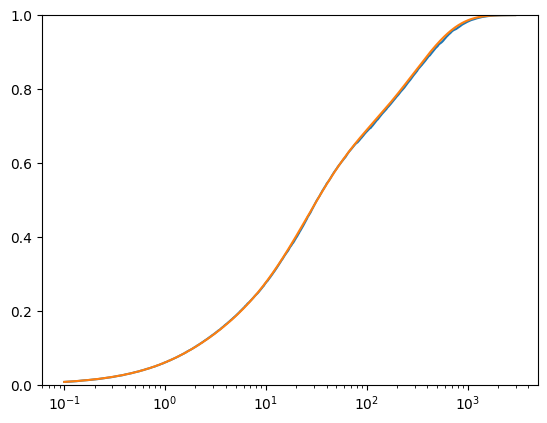

In [37]:
plt.semilogx(ts_long, age_CDF_long)
plt.semilogx(ts_long, analytical_aproximation)
plt.ylim(0, 1)